In [69]:
from astropy.table import Table
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

FLA  = 'FLAMES-30Dor-6563'
LVM_25   = 'LVM-30Dor-6563_25'
LVM_50   = 'LVM-30Dor-6563_50'
LVM_100  = 'LVM-30Dor-6563_100'
LVM_150  = 'LVM-30Dor-6563_150'
LVM_200  = 'LVM-30Dor-6563_200'
LVM_250  = 'LVM-30Dor-6563_subrot-01'
MUSE     = 'MUSE-Dor-H-bin0'

In [70]:
with fits.open(LVM_150 + '.fits') as hdul:
    hdul.info()

Filename: LVM-30Dor-6563_150.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      28   ()      
  1  LVM-30DOR-6563_A    1 BinTableHDU     23   11846R x 7C   [D, D, D, D, D, D, D]   
  2  TABLE         1 BinTableHDU     19   42R x 5C   [D, D, D, D, D]   
  3  PARAMETERS    1 BinTableHDU     19   3R x 5C   [D, D, D, D, D]   


In [71]:
with fits.open(MUSE + '.fits') as hdul:
    hdul.info()

Filename: MUSE-Dor-H-bin0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (560, 590)   float64   
  2  MOM1          1 ImageHDU         8   (560, 590)   float64   
  3  MOM2          1 ImageHDU         8   (560, 590)   float64   
  4  MASK          1 ImageHDU         8   (560, 590)   uint8   
  5  TABLE         1 BinTableHDU     23   58R x 7C   [D, D, D, D, K, D, D]   
  6  PARAMETERS    1 BinTableHDU     19   3R x 5C   [D, D, D, D, D]   


In [15]:
data_FLA = Table.read(FLA + ".fits", hdu='TABLE')
FLA_frame = data_FLA.to_pandas()

In [51]:
data_LVM_25 = Table.read(LVM_25 + ".fits", hdu='TABLE')
LVM_25_frame = data_LVM_25.to_pandas()

data_LVM_50 = Table.read(LVM_50 + ".fits", hdu='TABLE')
LVM_50_frame = data_LVM_50.to_pandas()

data_LVM_100 = Table.read(LVM_100 + ".fits", hdu='TABLE')
LVM_100_frame = data_LVM_100.to_pandas()

data_LVM_150 = Table.read(LVM_150 + ".fits", hdu='TABLE')
LVM_150_frame = data_LVM_150.to_pandas()

data_LVM_200 = Table.read(LVM_200 + ".fits", hdu='TABLE')
LVM_200_frame = data_LVM_200.to_pandas()

data_LVM_250 = Table.read(LVM_250 + ".fits", hdu='TABLE')
LVM_250_frame = data_LVM_250.to_pandas()

In [19]:
data_MUSE = Table.read(MUSE + ".fits", hdu='TABLE')
MUSE_frame = data_MUSE.to_pandas()

In [31]:
B_FLA        = np.array(FLA_frame['Unweighted B(r)'])
r_FLA        = np.array(10 ** np.array(FLA_frame['log10 r']))

In [54]:
B_LVM_25        = np.array(LVM_25_frame['Unweighted B(r)'])
r_LVM_25        = np.array(10 ** np.array(LVM_25_frame['log10 r']))

B_LVM_50        = np.array(LVM_50_frame['Unweighted B(r)'])
r_LVM_50        = np.array(10 ** np.array(LVM_50_frame['log10 r']))

B_LVM_100        = np.array(LVM_100_frame['Unweighted B(r)'])
r_LVM_100        = np.array(10 ** np.array(LVM_100_frame['log10 r']))

B_LVM_150        = np.array(LVM_150_frame['Unweighted B(r)'])
r_LVM_150        = np.array(10 ** np.array(LVM_150_frame['log10 r']))

B_LVM_200        = np.array(LVM_200_frame['Unweighted B(r)'])
r_LVM_200        = np.array(10 ** np.array(LVM_200_frame['log10 r']))

B_LVM_250        = np.array(LVM_250_frame['Unweighted B(r)'])
r_LVM_250        = np.array(10 ** np.array(LVM_250_frame['log10 r']))

In [63]:
with fits.open(MUSE + ".fits") as hdul:
    hdr = hdul[0].header

sig2_MUSE      = hdul[0].header['SIG2']
pc_MUSE        = hdul[0].header['PC']
pix_MUSE       = hdul[0].header['PIX']

mask = np.array(MUSE_frame["N pairs"]) > 0
B_MUSE        = np.array(MUSE_frame['Unweighted B(r)'])[mask]
r_MUSE        = np.array(10 ** np.array(MUSE_frame['log10 r'])* pix_MUSE * pc_MUSE)[mask]

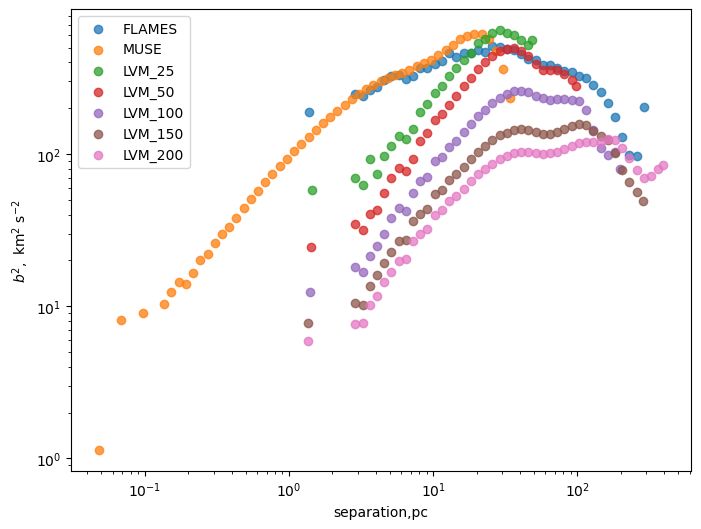

In [62]:
fig, ax = plt.subplots(figsize=(8, 6))


ax.scatter(r_FLA,B_FLA, label = 'FLAMES', alpha = 0.75)
ax.scatter(r_MUSE,B_MUSE, label = 'MUSE', alpha = 0.75)
ax.scatter(r_LVM_25,B_LVM_25, label = 'LVM_25', alpha = 0.75)
ax.scatter(r_LVM_50,B_LVM_50, label = 'LVM_50', alpha = 0.75)
ax.scatter(r_LVM_100,B_LVM_100, label = 'LVM_100', alpha = 0.75)
ax.scatter(r_LVM_150,B_LVM_150, label = 'LVM_150', alpha = 0.75)
ax.scatter(r_LVM_200,B_LVM_200, label = 'LVM_200', alpha = 0.75)

ax.legend()
ax.set(xscale='log', yscale='log', 
       xlabel='separation,pc',
       ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$'
      )
None